In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (ConfusionMatrixDisplay,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             confusion_matrix,
                             precision_recall_curve,
                             classification_report)


In [135]:
df = pd.read_csv(r'D:\Hoc-May\Lam_Bai_Lab\01-Phan-loai\TT-06-Naive-Bayes\SMSSpamCollection.csv',
                header = None,
                sep = '\t',
                names = ['label','message'],
                encoding='latin-1')
df.shape

(5572, 2)

In [136]:
print(f"Có {df.duplicated().sum()} mẫu trùng lặp tin nhắn")
#xóa các tin nhắn bị trùng
df = df.drop_duplicates(subset = 'message', keep = 'first')
print(f"Đã xóa những mẫu trùng lặp")

Có 403 mẫu trùng lặp tin nhắn
Đã xóa những mẫu trùng lặp


In [218]:
df['message_length'] = df['message'].str.len()
print(f"{df.groupby('label')['message_length'].describe()}")
df.shape


        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.987600  56.736845   2.0   34.0   53.0   91.0  910.0
spam    653.0  138.130168  29.937254  13.0  132.0  149.0  157.0  224.0


(5169, 3)

Nhìn biểu đồ ta thấy xu hướng của spam là có độ dài dài hơn 


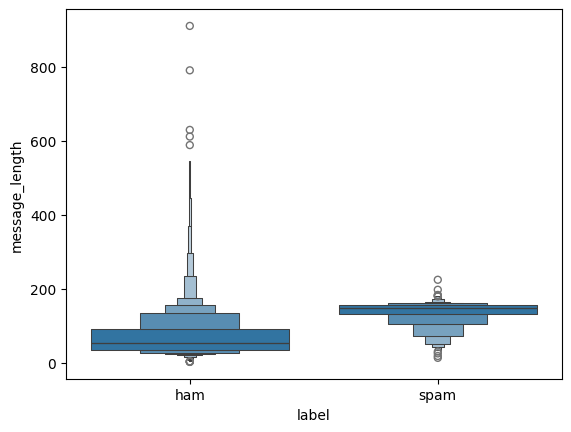

In [138]:
import seaborn as sns  

sns.boxenplot(data=df,x='label',y='message_length')

print('Nhìn biểu đồ ta thấy xu hướng của spam là có độ dài dài hơn ')


In [139]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(df.drop(['label'], axis = 1),df['label'],test_size = 0.2,random_state = 42)

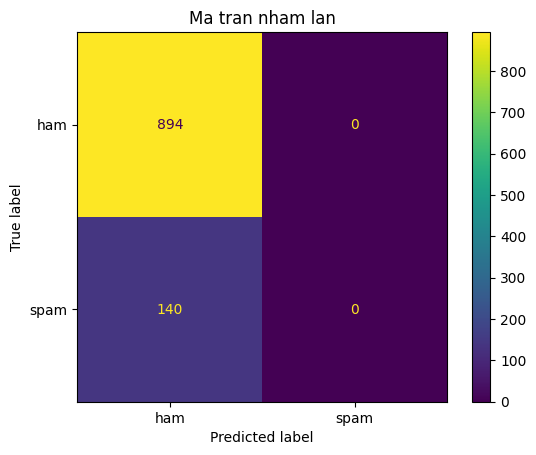

In [140]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy = 'most_frequent')

dummy.fit(x_train,y_train)

y_pred_dummy = dummy.predict(x_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred = y_pred_dummy,
    display_labels = ['ham','spam']
)
plt.title("Ma tran nham lan")
plt.show()


In [141]:
print(classification_report(y_test,y_pred_dummy))

              precision    recall  f1-score   support

         ham       0.86      1.00      0.93       894
        spam       0.00      0.00      0.00       140

    accuracy                           0.86      1034
   macro avg       0.43      0.50      0.46      1034
weighted avg       0.75      0.86      0.80      1034



c:\Users\hieum\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hieum\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hieum\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

(array([3.469e+03, 1.575e+03, 7.400e+01, 3.200e+01, 1.100e+01, 3.000e+00,
        3.000e+00, 0.000e+00, 1.000e+00, 1.000e+00]),
 array([  2. ,  92.8, 183.6, 274.4, 365.2, 456. , 546.8, 637.6, 728.4,
        819.2, 910. ]),
 <BarContainer object of 10 artists>)

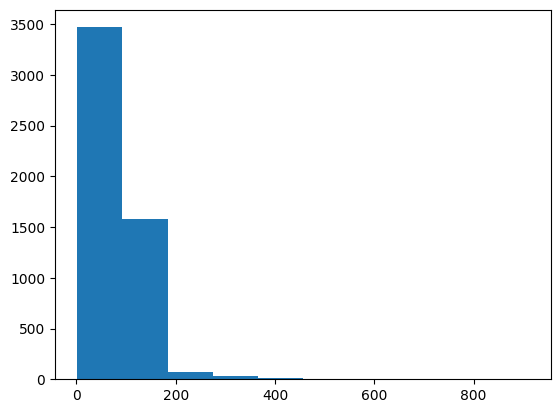

In [142]:
plt.hist(df["message_length"])

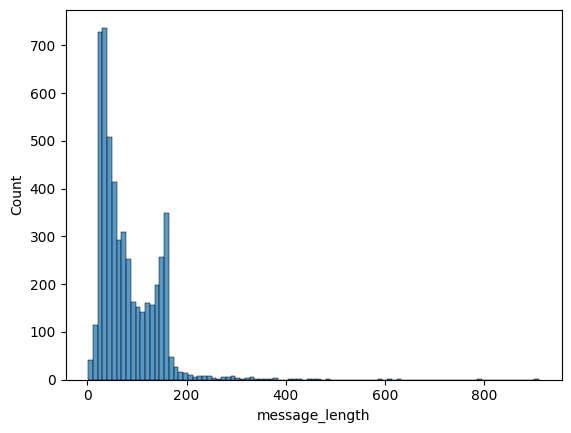

In [143]:
sns.histplot(df["message_length"])
plt.savefig(
    "do_dai_tin.png",
    dpi=300,
    bbox_inches="tight"
)

CountVectorizer + MultinomialNB

In [144]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('text', CountVectorizer(), 'message'),
        ('length', 'passthrough', ['message_length'])
    ],
)
pipeline_count_mul = make_pipeline(
    preprocessor,
    MultinomialNB()
)

param_grid_count_mul = {
    'columntransformer__text__ngram_range': [(1,1), (1,2)],
    'columntransformer__text__min_df': [2,3,4],
    'columntransformer__text__max_df': [0.8,0.9,0.95],
    'columntransformer__text__lowercase': [True],
    'multinomialnb__alpha': [0.01,0.1,0.5,1.0]
}

grid_count_mul = GridSearchCV(
    pipeline_count_mul,
    param_grid_count_mul,
    cv = 5,
    scoring='f1_macro',
    n_jobs = -1,
)

grid_count_mul.fit(x_train,y_train)

print(grid_count_mul.best_params_)
print(grid_count_mul.best_score_)


{'columntransformer__text__lowercase': True, 'columntransformer__text__max_df': 0.8, 'columntransformer__text__min_df': 2, 'columntransformer__text__ngram_range': (1, 1), 'multinomialnb__alpha': 0.5}
0.9693673072076203


TfidfVectorizer + MultinomialNB

In [145]:
preprocessor_2 = ColumnTransformer(
    transformers = [
        ('text',TfidfVectorizer(),'message'),
        ('length','passthrough',['message_length'])
    ]
)
pipeline_tfi_mul = make_pipeline(
    preprocessor_2,
    MultinomialNB()
)

param_grid_tfi_mul = {
    'columntransformer__text__lowercase': [True],
    'columntransformer__text__ngram_range': [(1,1),(1,2)],
    'columntransformer__text__min_df': [2,3,4],
    'columntransformer__text__max_df': [0.8,0.9,0.95],
    'columntransformer__text__sublinear_tf': [True],
    'multinomialnb__alpha': [0.01,0.1,0.5,1]
}

grid_tfi_mul = GridSearchCV(
    pipeline_tfi_mul,
    param_grid_tfi_mul,
    cv = 5,
    scoring = 'f1_macro',
    n_jobs = -1
)
grid_tfi_mul.fit(x_train,y_train)
print(grid_tfi_mul.best_params_)
print(grid_tfi_mul.best_score_)


{'columntransformer__text__lowercase': True, 'columntransformer__text__max_df': 0.8, 'columntransformer__text__min_df': 4, 'columntransformer__text__ngram_range': (1, 1), 'columntransformer__text__sublinear_tf': True, 'multinomialnb__alpha': 0.1}
0.9675623484085423


TfidfVectorizer + BernoulliNB

In [146]:
from sklearn.naive_bayes import BernoulliNB

preprocessor_3 = ColumnTransformer(
    transformers = [
        ('text', TfidfVectorizer(),'message'),
        ('length','passthrough',['message_length'])
    ]
)

pipeline_tfi_ber = make_pipeline(
    preprocessor_3,
    BernoulliNB()
)

param_grid_tfi_ber = {
    'columntransformer__text__lowercase':[True],
    'columntransformer__text__min_df':[2,3,4],
    'columntransformer__text__max_df':[0.8,0.9,0.95],
    'columntransformer__text__ngram_range':[(1,1),(1,2)],
    'columntransformer__text__sublinear_tf': [True],
    'bernoullinb__alpha': [0.01,0.1,0.5,1]    
}

grid_tfi_ber = GridSearchCV(
    pipeline_tfi_ber,
    param_grid_tfi_ber,
    cv = 5,
    scoring = 'f1_macro',
    n_jobs = 1
)

grid_tfi_ber.fit(x_train,y_train)
print(grid_tfi_ber.best_params_)
print(grid_tfi_ber.best_score_)


{'bernoullinb__alpha': 0.1, 'columntransformer__text__lowercase': True, 'columntransformer__text__max_df': 0.8, 'columntransformer__text__min_df': 4, 'columntransformer__text__ngram_range': (1, 1), 'columntransformer__text__sublinear_tf': True}
0.9728352444470438


In [147]:
comparison = pd.DataFrame([
    {
        'Model': 'CountVectorizer + MultinomialNB',
        'F1 Macro': grid_count_mul.best_score_,
        'Alpha': grid_count_mul.best_params_['multinomialnb__alpha'],
        'Ngram': grid_count_mul.best_params_['columntransformer__text__ngram_range'],
        'Min DF': grid_count_mul.best_params_['columntransformer__text__min_df'],
        'Max DF': grid_count_mul.best_params_['columntransformer__text__max_df']
    },
    {
        'Model': 'TfidfVectorizer + MultinomialNB',
        'F1 Macro': grid_tfi_mul.best_score_,
        'Alpha': grid_tfi_mul.best_params_['multinomialnb__alpha'],
        'Ngram': grid_tfi_mul.best_params_['columntransformer__text__ngram_range'],
        'Min DF': grid_tfi_mul.best_params_['columntransformer__text__min_df'],
        'Max DF': grid_tfi_mul.best_params_['columntransformer__text__max_df']
    },
    {
        'Model': 'TfidfVectorizer + BernoulliNB',
        'F1 Macro': grid_tfi_ber.best_score_,
        'Alpha': grid_tfi_ber.best_params_['bernoullinb__alpha'],
        'Ngram': grid_tfi_ber.best_params_['columntransformer__text__ngram_range'],
        'Min DF': grid_tfi_ber.best_params_['columntransformer__text__min_df'],
        'Max DF': grid_tfi_ber.best_params_['columntransformer__text__max_df']
    }
])

comparison

,Model,F1 Macro,Alpha,Ngram,Min DF,Max DF
0,CountVectorizer + MultinomialNB,0.969367,0.5,"(1, 1)",2,0.8
1,TfidfVectorizer + MultinomialNB,0.967562,0.1,"(1, 1)",4,0.8
2,TfidfVectorizer + BernoulliNB,0.972835,0.1,"(1, 1)",4,0.8


In [148]:
best_model = grid_tfi_ber.best_estimator_

nb =best_model.named_steps['bernoullinb']

vectorizer = (
    best_model.named_steps['columntransformer'].named_transformers_['text']
)

feature_names = vectorizer.get_feature_names_out()

spam_index = list(nb.classes_).index('spam')
spam_log_prob = nb.feature_log_prob_[spam_index][:len(feature_names)]
top20_indices = np.argsort(spam_log_prob)[-20:][::-1]
print('Những từ có xác suất xuất hiện cao nhất trong SPAM')
for rank,idx in enumerate(top20_indices,1):
    print(rank,feature_names[idx],spam_log_prob[idx])

Những từ có xác suất xuất hiện cao nhất trong SPAM
1 to -0.465803576404328
2 call -0.8603075558572355
3 you -1.1161065923269113
4 your -1.1463021231145136
5 for -1.357106421213202
6 now -1.4195779405309201
7 or -1.4523409036555437
8 free -1.5035903758734515
9 the -1.5035903758734515
10 is -1.6344959464203068
11 txt -1.6752763167652347
12 from -1.7397454681271896
13 have -1.808659065762579
14 text -1.8327276162830985
15 mobile -1.844982671620114
16 on -1.8573897786671676
17 ur -1.895562352172198
18 claim -1.9352501004394398
19 reply -1.962611588450578
20 and -1.962611588450578


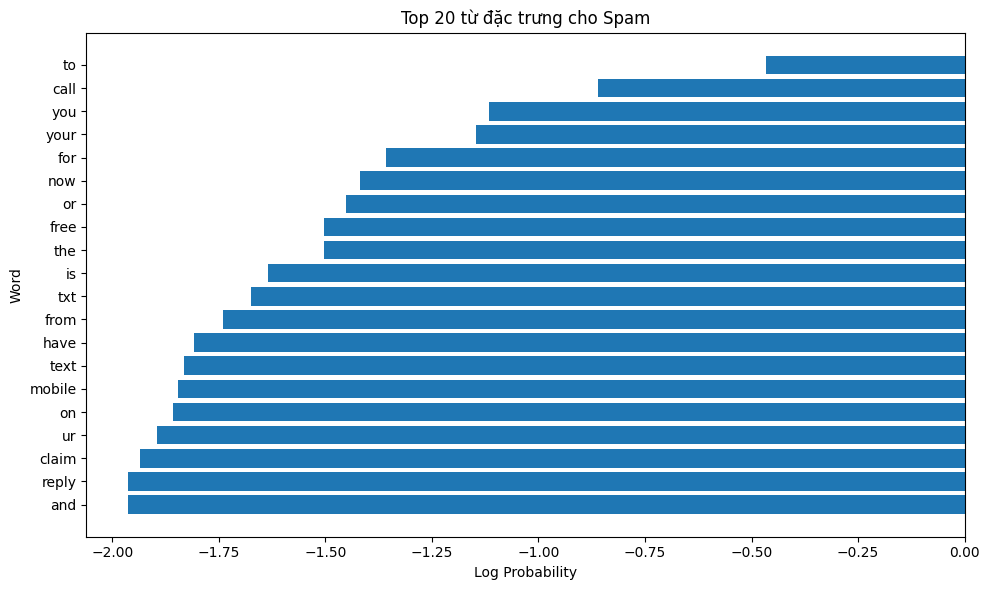

In [149]:
top20_words = feature_names[top20_indices]
top20_scores = spam_log_prob[top20_indices]
plt.figure(figsize=(10, 6))
plt.barh(top20_words[::-1], top20_scores[::-1])
plt.xlabel("Log Probability")
plt.ylabel("Word")
plt.title("Top 20 từ đặc trưng cho Spam")
plt.tight_layout()

plt.savefig("top_tu_spam.png", dpi=300, bbox_inches="tight")
plt.show()

In [150]:
best_model = grid_tfi_ber.best_estimator_

nb = best_model.named_steps['bernoullinb']

vectorizer = (
    best_model
    .named_steps['columntransformer']
    .named_transformers_['text']
)

feature_names = vectorizer.get_feature_names_out()

# Tìm vị trí của spam và ham
spam_index = list(nb.classes_).index('spam')
ham_index = list(nb.classes_).index('ham')

# Lấy log probability
spam_log_prob = nb.feature_log_prob_[spam_index][:len(feature_names)]
ham_log_prob = nb.feature_log_prob_[ham_index][:len(feature_names)]

# Mức độ nghiêng về Spam
spam_score = spam_log_prob - ham_log_prob

# TOP 20 từ nghiêng về Spam mạnh nhất
top20_indices = np.argsort(spam_score)[-20:][::-1]

print('Những từ phân biệt SPAM với HAM mạnh nhất')
for rank, idx in enumerate(top20_indices, 1):
    print(
        rank,
        feature_names[idx],
        spam_score[idx]
    )

Những từ phân biệt SPAM với HAM mạnh nhất
1 claim 8.562171847585041
2 prize 8.228933243530893
3 150p 8.065638561791634
4 16 7.786053699572471
5 guaranteed 7.756289597666017
6 18 7.756289597666017
7 tone 7.592525891622699
8 cs 7.556290043168655
9 awarded 7.556290043168655
10 1000 7.556290043168655
11 500 7.518691629611648
12 ringtone 7.306029355765021
13 150ppm 7.306029355765021
14 10p 7.206444650335584
15 000 7.095834778791614
16 valid 7.095834778791614
17 tones 7.095834778791614
18 http 7.095834778791614
19 collection 7.035575587273417
20 weekly 7.035575587273417


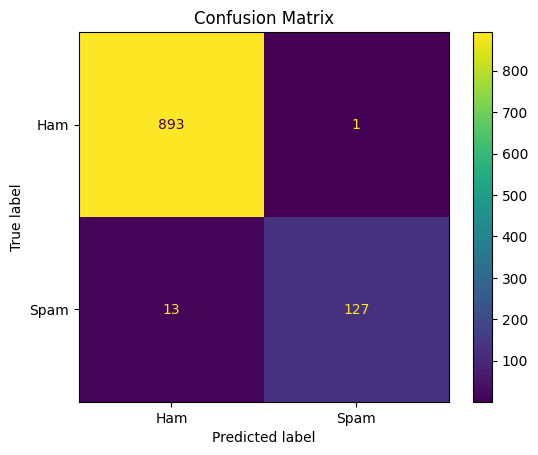

In [151]:
y_pred = best_model.predict(x_test)
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['ham', 'spam']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)

disp.plot()
plt.title("Confusion Matrix")

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [152]:
import numpy as np


y_prob = best_model.predict_proba(x_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob,
    pos_label='spam'
)

valid = precision[:-1] >= 0.98

if valid.any():

    # Lấy threshold thấp nhất nhưng vẫn đạt Precision >= 0.98
    idx = np.where(valid)[0][0]

    threshold = thresholds[idx]
    precision_selected = precision[idx]
    recall_selected = recall[idx]

    print("Threshold:", threshold)
    print("Precision:", precision_selected)
    print("Recall:", recall_selected)

else:
    print("Không tìm được threshold có Precision >= 0.98")

Threshold: 0.06579275955136463
Precision: 0.9850746268656716
Recall: 0.9428571428571428


In [153]:
y_pred_custom = np.where(
    y_prob >= threshold,
    'spam',
    'ham'
)

In [154]:
wrong_idx = np.where(y_test != y_pred_custom)[0]

print("Số tin bị sai:", len(wrong_idx))

Số tin bị sai: 10


In [155]:
wrong_positions = np.where(y_test.to_numpy() != y_pred_custom)[0]

for pos in wrong_positions[:10]:
    print("Message:", x_test.iloc[pos]['message'])
    print("Thực tế:", y_test.iloc[pos])
    print("Dự đoán:", y_pred_custom[pos])
    print("Xác suất Spam:", y_prob[pos])
    print("-" * 80)

Message: Can u get pic msgs to your phone?
Thực tế: ham
Dự đoán: spam
Xác suất Spam: 0.41832757124898523
--------------------------------------------------------------------------------
Message: LIFE has never been this much fun and great until you came in. You made it truly special for me. I won't forget you! enjoy @ one gbp/sms
Thực tế: spam
Dự đoán: ham
Xác suất Spam: 2.7201508666692194e-08
--------------------------------------------------------------------------------
Message: Would you like to see my XXX pics they are so hot they were nearly banned in the uk!
Thực tế: spam
Dự đoán: ham
Xác suất Spam: 0.01175237269682244
--------------------------------------------------------------------------------
Message: Missed call alert. These numbers called but left no message. 07008009200
Thực tế: spam
Dự đoán: ham
Xác suất Spam: 2.9881540269822282e-06
--------------------------------------------------------------------------------
Message: Babe: U want me dont u baby! Im nasty and have a

In [156]:
print(best_model.classes_)

['ham' 'spam']


In [157]:
print("Threshold:", threshold)
print("Classes:", best_model.classes_)

for i in range(10):
    print(
        "prob =", y_prob[i],
        "manual =", 'spam' if y_prob[i] >= threshold else 'ham',
        "actual =", y_test.iloc[i]
    )

Threshold: 0.06579275955136463
Classes: ['ham' 'spam']
prob = 2.16139744146546e-15 manual = ham actual = ham
prob = 1.0 manual = spam actual = spam
prob = 3.892102264362102e-09 manual = ham actual = ham
prob = 2.6685364180621783e-10 manual = ham actual = ham
prob = 1.0 manual = spam actual = spam
prob = 9.544967226258097e-05 manual = ham actual = ham
prob = 1.2655897782402026e-06 manual = ham actual = ham
prob = 1.1997882094606703e-06 manual = ham actual = ham
prob = 1.0 manual = spam actual = spam
prob = 3.407840187282539e-09 manual = ham actual = ham


In [158]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = make_pipeline(
    preprocessor_3,   # TF-IDF + message_length
    LogisticRegression(max_iter=1000)
)

param_grid_lr = {
    'columntransformer__text__lowercase': [True],
    'columntransformer__text__ngram_range': [(1,1), (1,2)],
    'columntransformer__text__min_df': [2,3,4],
    'columntransformer__text__max_df': [0.8,0.9,0.95],
    'columntransformer__text__sublinear_tf': [True],
    'logisticregression__C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_lr.fit(x_train, y_train)

print(grid_lr.best_params_)
print(grid_lr.best_score_)

{'columntransformer__text__lowercase': True, 'columntransformer__text__max_df': 0.8, 'columntransformer__text__min_df': 4, 'columntransformer__text__ngram_range': (1, 2), 'columntransformer__text__sublinear_tf': True, 'logisticregression__C': 10}
0.9590234146371884


In [159]:

best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(x_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       894
        spam       0.99      0.93      0.96       140

    accuracy                           0.99      1034
   macro avg       0.99      0.96      0.98      1034
weighted avg       0.99      0.99      0.99      1034



In [160]:
best_ber = grid_tfi_ber.best_estimator_

y_pred_ber = best_ber.predict(x_test)

print(classification_report(y_test, y_pred_ber))

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       894
        spam       0.99      0.91      0.95       140

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034



In [219]:
import joblib
joblib.dump(best_ber, "nb_pipeline.joblib")

['nb_pipeline.joblib']

In [201]:
import time

start = time.perf_counter()

best_model.fit(x_train, y_train)

train_time = time.perf_counter() - start

print(f"Train time: {train_time:.4f} seconds")

Train time: 0.0868 seconds


In [202]:
import time

one_message = x_test.iloc[[0]]

start = time.perf_counter()

prediction = best_model.predict(one_message)

predict_time = (time.perf_counter() - start) * 1000

print("Prediction:", prediction[0])
print(f"Prediction time: {predict_time:.4f} ms")

Prediction: ham
Prediction time: 4.7580 ms


In [203]:
import time

start = time.perf_counter()

best_lr.fit(x_train, y_train)

train_time = time.perf_counter() - start

print(f"Train time: {train_time:.4f} seconds")

Train time: 0.4466 seconds


In [214]:
import time

one_message = x_test.iloc[[0]]

start = time.perf_counter()

prediction = best_lr.predict(one_message)

predict_time = (time.perf_counter() - start) * 1000

print("Prediction:", prediction[0])
print(f"Prediction time: {predict_time:.4f} ms")

Prediction: ham
Prediction time: 6.5099 ms


In [220]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import GridSearchCV

pipeline_tfidf_ber_no_length = make_pipeline(
    TfidfVectorizer(),
    BernoulliNB()
)

param_grid_tfidf_ber_no_length = {
    'tfidfvectorizer__lowercase': [True],
    'tfidfvectorizer__min_df': [2, 3, 4],
    'tfidfvectorizer__max_df': [0.8, 0.9, 0.95],
    'tfidfvectorizer__ngram_range': [(1,1), (1,2)],
    'tfidfvectorizer__sublinear_tf': [True],
    'bernoullinb__alpha': [0.01, 0.1, 1]
}

grid_no_length = GridSearchCV(
    pipeline_tfidf_ber_no_length,
    param_grid_tfidf_ber_no_length,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_no_length.fit(
    x_train['message'],
    y_train
)

print(grid_no_length.best_params_)
print(grid_no_length.best_score_)

{'bernoullinb__alpha': 0.1, 'tfidfvectorizer__lowercase': True, 'tfidfvectorizer__max_df': 0.8, 'tfidfvectorizer__min_df': 4, 'tfidfvectorizer__ngram_range': (1, 1), 'tfidfvectorizer__sublinear_tf': True}
0.9728352444470438


In [221]:
from sklearn.metrics import classification_report

best_no_length = grid_no_length.best_estimator_

y_pred_no_length = best_no_length.predict(
    x_test['message']
)

print(classification_report(y_test, y_pred_no_length))

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       894
        spam       0.99      0.91      0.95       140

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034



Trộn message_length thô (chưa chuẩn hoá) với TF-IDF/CountVectorizer vào MultinomialNB cũng không đúng bản chất xác suất (MultinomialNB kỳ vọng đặc trưng là "đếm sự kiện rời rạc", không phải một số liên tục lớn). Vẫn chạy được về mặt kỹ thuật nhưng sai giả định mô hình — Nó có thể giúp ích vì nó vẫn ở dạng số nguyên lớn và có thể có mối tương quan hoặc giúp ích gì đó cho model học hỏi và dự đoán. Chúng ta có thể thử nghiệm có message_length hoặc không cần. Nhưng ở đây thì nó không giúp ích gì nhiều

In [223]:
import numpy
import pandas
import sklearn
import matplotlib
import seaborn
import joblib
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)
print("joblib:", joblib.__version__)

numpy: 2.2.6
pandas: 2.3.3
scikit-learn: 1.6.1
matplotlib: 3.10.1
seaborn: 0.13.2
joblib: 1.4.2
